**How to use implemented MLP**

In [1]:
from Engine import CppModule as module
from Utils.Draw_nn import draw_dot
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
X = [2.0,3.0,-1.0]
mlp = module.MLP()
mlp.Linear(3,4)
mlp.Linear(4,4)
mlp.Linear(4,1)
out = mlp(X) #Feed Forward
out

Value(data=-1.28833, grad=0, label='')

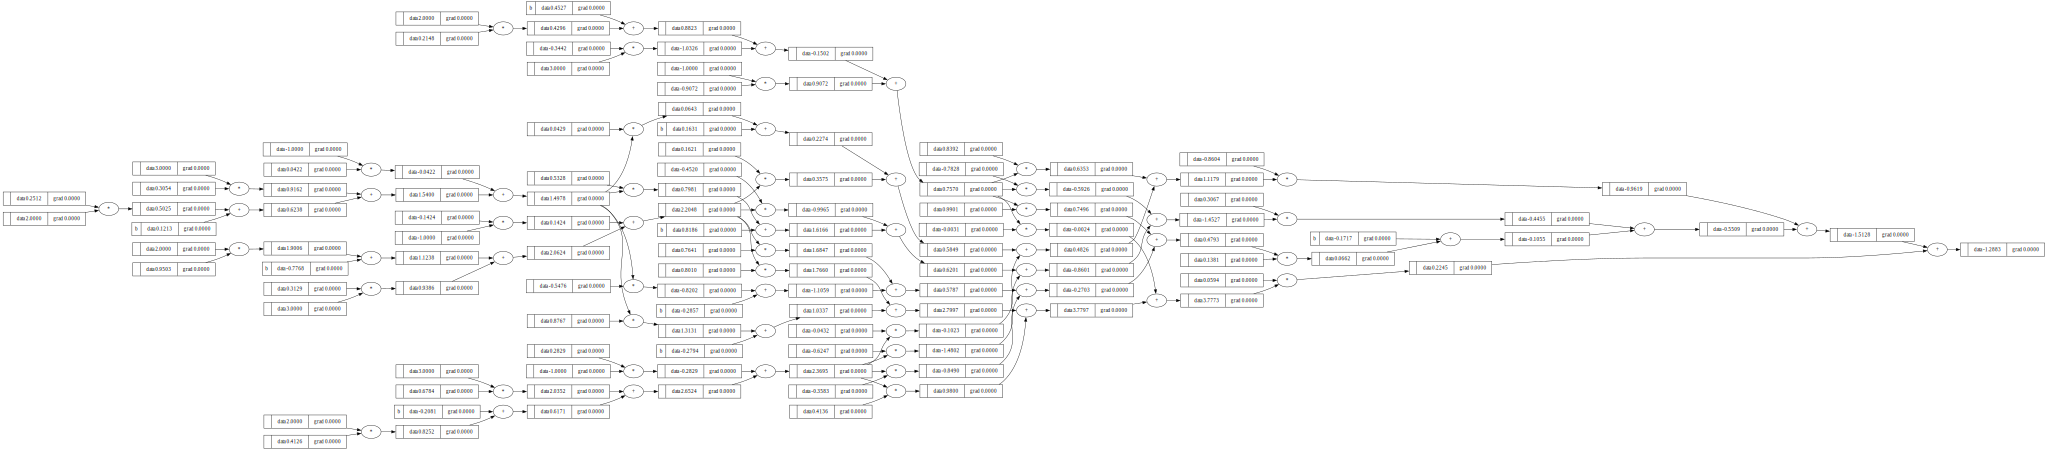

In [3]:
draw_dot(out)

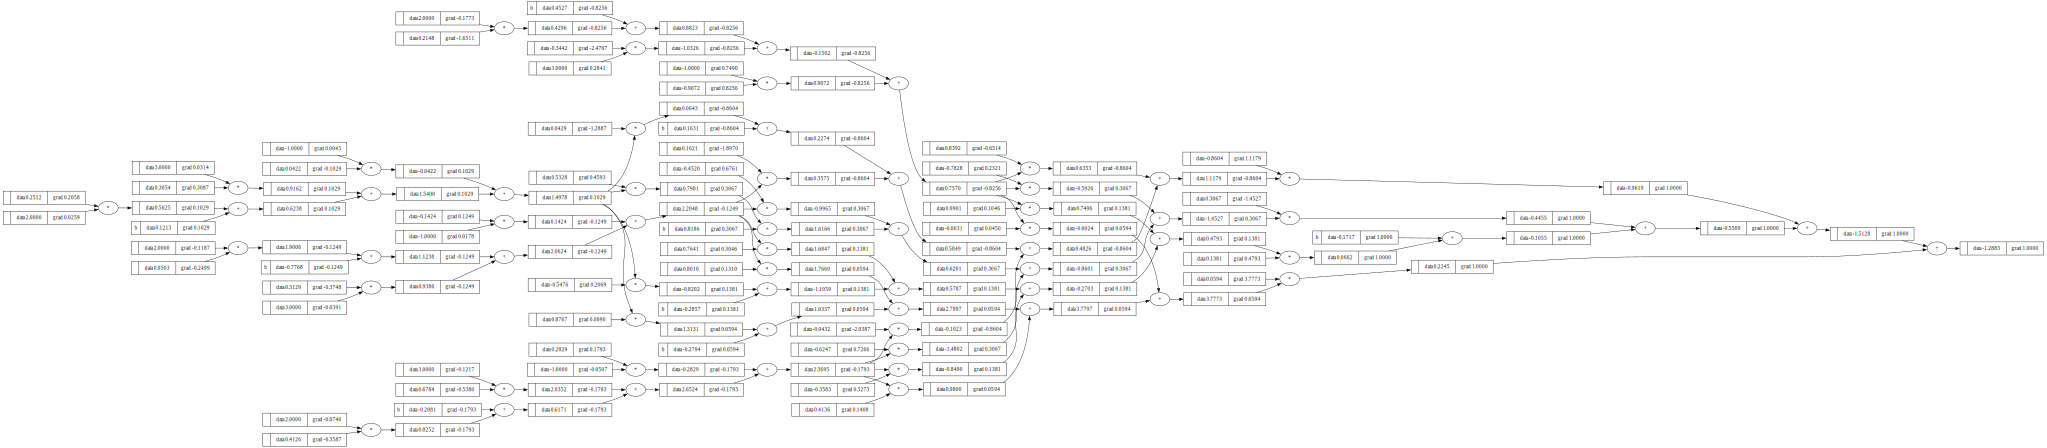

In [4]:
out.backward()
draw_dot(out)

**Example showing how it learn**

In [5]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [6]:
mlp = module.MLP()
mlp.Linear(3,4)
mlp.Tanh()
mlp.Linear(4,4)
mlp.Tanh()
mlp.Linear(4,1)

In [7]:
for i in range(20):
    #Feed Forward
    out = [mlp(x) for x in xs]

    mlp.zero_grad()
    loss = sum(((y_gd - y_pred)**2 for y_gd,y_pred in zip(ys,out)))

    
    loss.backward()
    mlp.step(lr = 0.01)
    
    print(f"Loss: {loss}")
loss

Loss: Value(data=2.90009, grad=1, label='')
Loss: Value(data=2.36521, grad=1, label='')
Loss: Value(data=1.93605, grad=1, label='')
Loss: Value(data=1.57763, grad=1, label='')
Loss: Value(data=1.27446, grad=1, label='')
Loss: Value(data=1.01887, grad=1, label='')
Loss: Value(data=0.805777, grad=1, label='')
Loss: Value(data=0.630659, grad=1, label='')
Loss: Value(data=0.488908, grad=1, label='')
Loss: Value(data=0.37583, grad=1, label='')
Loss: Value(data=0.286841, grad=1, label='')
Loss: Value(data=0.217656, grad=1, label='')
Loss: Value(data=0.164446, grad=1, label='')
Loss: Value(data=0.1239, grad=1, label='')
Loss: Value(data=0.0932491, grad=1, label='')
Loss: Value(data=0.0702305, grad=1, label='')
Loss: Value(data=0.053036, grad=1, label='')
Loss: Value(data=0.0402451, grad=1, label='')
Loss: Value(data=0.0307581, grad=1, label='')
Loss: Value(data=0.0237342, grad=1, label='')


Value(data=0.0237342, grad=1, label='')

In [8]:
out

[Value(data=0.891799, grad=-0.216401, label=''),
 Value(data=-0.956512, grad=0.0869769, label=''),
 Value(data=-0.900152, grad=0.199697, label=''),
 Value(data=0.987121, grad=-0.0257585, label='')]

**Compare Results with Torch MLP**

In [9]:
# 1. Convert your lists to PyTorch Tensors
xs = torch.tensor(xs, dtype=torch.float32)
ys = torch.tensor(ys, dtype=torch.float32).view(-1,1)

model = nn.Sequential(
    nn.Linear(3, 4),
    nn.Tanh(), 
    nn.Linear(4, 4),
    nn.Tanh(),
    nn.Linear(4, 1)
)

# reduction='sum' matches `sum((y_gd - y_pred)**2)` logic
criterion = nn.MSELoss(reduction='sum')

optimizer = optim.SGD(model.parameters(), lr=0.01)

# 4. Training Loop
for i in range(20):
    #Feed Forward
    out = model(xs)
    
    # Calculate loss
    loss = criterion(out, ys)
    
    # Zero gradients, perform backward pass, and update weights
    optimizer.zero_grad()  # Equivalent to loss.zero_grad()
    loss.backward()        # Equivalent to loss.backward()
    optimizer.step()       # Equivalent to loss.update()

print(f"Final Loss: {loss.item():.4f}") 

print("Final Predictions:")
print(out.detach())

Final Loss: 2.1890
Final Predictions:
tensor([[ 0.3409],
        [-0.0788],
        [-0.4189],
        [ 0.2462]])
